## 0 Necesario para la API

In [1]:
import sys
import os

# Esto agrega la carpeta raíz de tu proyecto al camino de búsqueda de Python
# Asegurate de que la ruta sea la correcta hacia la carpeta 'taxis-nyc'
ruta_proyecto = os.path.abspath(os.path.join(os.getcwd(), '..')) 

if ruta_proyecto not in sys.path:
    sys.path.append(ruta_proyecto)

# Ahora el import ya debería funcionar
from src.transformers import AtributosTemporales, mapeoABarrios, EliminarColumnas, numeroAString

## 1 Importo los datos

In [2]:
import pandas as pd

#URL oficial del dataset de Yellow Taxis para Enero 2025
url = "https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2025-01.parquet"

#Importo los datos
taxis = pd.read_parquet(url)

## 2 Inspección de la estructura

In [3]:
taxis.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
0,1,2025-01-01 00:18:38,2025-01-01 00:26:59,1.0,1.60,1.0,N,229,237,1,10.0,3.5,0.5,3.00,0.0,1.0,18.00,2.5,0.0,0.0
1,1,2025-01-01 00:32:40,2025-01-01 00:35:13,1.0,0.50,1.0,N,236,237,1,5.1,3.5,0.5,2.02,0.0,1.0,12.12,2.5,0.0,0.0
2,1,2025-01-01 00:44:04,2025-01-01 00:46:01,1.0,0.60,1.0,N,141,141,1,5.1,3.5,0.5,2.00,0.0,1.0,12.10,2.5,0.0,0.0
3,2,2025-01-01 00:14:27,2025-01-01 00:20:01,3.0,0.52,1.0,N,244,244,2,7.2,1.0,0.5,0.00,0.0,1.0,9.70,0.0,0.0,0.0
4,2,2025-01-01 00:21:34,2025-01-01 00:25:06,3.0,0.66,1.0,N,244,116,2,5.8,1.0,0.5,0.00,0.0,1.0,8.30,0.0,0.0,0.0


In [4]:
taxis.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3475226 entries, 0 to 3475225
Data columns (total 20 columns):
 #   Column                 Non-Null Count    Dtype         
---  ------                 --------------    -----         
 0   VendorID               3475226 non-null  int32         
 1   tpep_pickup_datetime   3475226 non-null  datetime64[us]
 2   tpep_dropoff_datetime  3475226 non-null  datetime64[us]
 3   passenger_count        2935077 non-null  float64       
 4   trip_distance          3475226 non-null  float64       
 5   RatecodeID             2935077 non-null  float64       
 6   store_and_fwd_flag     2935077 non-null  object        
 7   PULocationID           3475226 non-null  int32         
 8   DOLocationID           3475226 non-null  int32         
 9   payment_type           3475226 non-null  int64         
 10  fare_amount            3475226 non-null  float64       
 11  extra                  3475226 non-null  float64       
 12  mta_tax                34752

**Columnas con más de 1% de datos faltantes**

Sobre las columnas que tengan más de 1% de datos faltantes no voy a usar métodos como drop_na(), sino que voy a usar simpleImputer con algún criterio.

In [5]:
#Calculo el porcentaje de faltantes por columna
porcentaje_nulos = (taxis.isnull().sum() / len(taxis)) * 100

#Creo una tupla de nombres de columnas:
col_con_faltantes = tuple(porcentaje_nulos[porcentaje_nulos >= 1].index)

#Muestro el resultado con el porcentaje:
print(f"Columnas con más del 1% de nulos (Tupla): {col_con_faltantes}")
print("-" * 50)
print(porcentaje_nulos[porcentaje_nulos >= 1].sort_values(ascending=False))

Columnas con más del 1% de nulos (Tupla): ('passenger_count', 'RatecodeID', 'store_and_fwd_flag', 'congestion_surcharge', 'Airport_fee')
--------------------------------------------------
passenger_count         15.542845
RatecodeID              15.542845
store_and_fwd_flag      15.542845
congestion_surcharge    15.542845
Airport_fee             15.542845
dtype: float64


Existen filas donde la información del "viaje" (metros, tiempos, montos) está, pero la información "administrativa" (cuántos pasajeros, qué tarifa se aplicó, si hubo recargos) es completamente nula. Es un bloque de datos faltantes que afecta a varias columnas al mismo tiempo, en todas falta exactamente el mismo porcentaje.

### 2.1 Inspección según si la variable es numérica o categórica

In [6]:
import numpy as np
#Divido el data set
columnas_num = taxis.select_dtypes(include=[np.number]).columns
columnas_cat = taxis.select_dtypes(exclude=[np.number]).columns
print(type(columnas_num))
print(type(columnas_cat))

<class 'pandas.core.indexes.base.Index'>
<class 'pandas.core.indexes.base.Index'>


#### 2.1.1 Inspección sobre variables numéricas

In [7]:
taxis.describe()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
count,3.475226e+06,3475226,3475226,2.935077e+06,3.475226e+06,2.935077e+06,3.475226e+06,3.475226e+06,3.475226e+06,3.475226e+06,3.475226e+06,3.475226e+06,3.475226e+06,3.475226e+06,3.475226e+06,3.475226e+06,2.935077e+06,2.935077e+06,3.475226e+06
mean,1.785428e+00,2025-01-17 11:02:55.910964,2025-01-17 11:17:56.997901,1.297859e+00,5.855126e+00,2.482535e+00,1.651916e+02,1.641252e+02,1.036623e+00,1.708180e+01,1.317737e+00,4.780991e-01,2.959813e+00,4.493081e-01,9.547946e-01,2.561129e+01,2.225237e+00,1.239111e-01,4.834093e-01
min,1.000000e+00,2024-12-31 20:47:55,2024-12-18 07:52:40,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,-9.000000e+02,-7.500000e+00,-5.000000e-01,-8.600000e+01,-1.269400e+02,-1.000000e+00,-9.010000e+02,-2.500000e+00,-1.750000e+00,-7.500000e-01
25%,2.000000e+00,2025-01-10 07:59:01,2025-01-10 08:15:29.500000,1.000000e+00,9.800000e-01,1.000000e+00,1.320000e+02,1.130000e+02,1.000000e+00,8.600000e+00,0.000000e+00,5.000000e-01,0.000000e+00,0.000000e+00,1.000000e+00,1.520000e+01,2.500000e+00,0.000000e+00,0.000000e+00
50%,2.000000e+00,2025-01-17 15:41:33,2025-01-17 15:59:34,1.000000e+00,1.670000e+00,1.000000e+00,1.620000e+02,1.620000e+02,1.000000e+00,1.211000e+01,0.000000e+00,5.000000e-01,2.450000e+00,0.000000e+00,1.000000e+00,1.995000e+01,2.500000e+00,0.000000e+00,7.500000e-01
75%,2.000000e+00,2025-01-24 19:34:06,2025-01-24 19:48:31,1.000000e+00,3.100000e+00,1.000000e+00,2.340000e+02,2.340000e+02,1.000000e+00,1.950000e+01,2.500000e+00,5.000000e-01,3.930000e+00,0.000000e+00,1.000000e+00,2.778000e+01,2.500000e+00,0.000000e+00,7.500000e-01
max,7.000000e+00,2025-02-01 00:00:44,2025-02-01 23:44:11,9.000000e+00,2.764236e+05,9.900000e+01,2.650000e+02,2.650000e+02,5.000000e+00,8.633721e+05,1.500000e+01,1.050000e+01,4.000000e+02,1.709400e+02,1.000000e+00,8.633804e+05,2.500000e+00,6.750000e+00,7.500000e-01
std,4.263282e-01,NaN,NaN,7.507503e-01,5.646016e+02,1.163277e+01,6.452948e+01,6.940169e+01,7.013334e-01,4.634729e+02,1.861509e+00,1.374623e-01,3.779681e+00,2.002582e+00,2.781938e-01,4.636585e+02,9.039932e-01,4.725090e-01,3.619307e-01


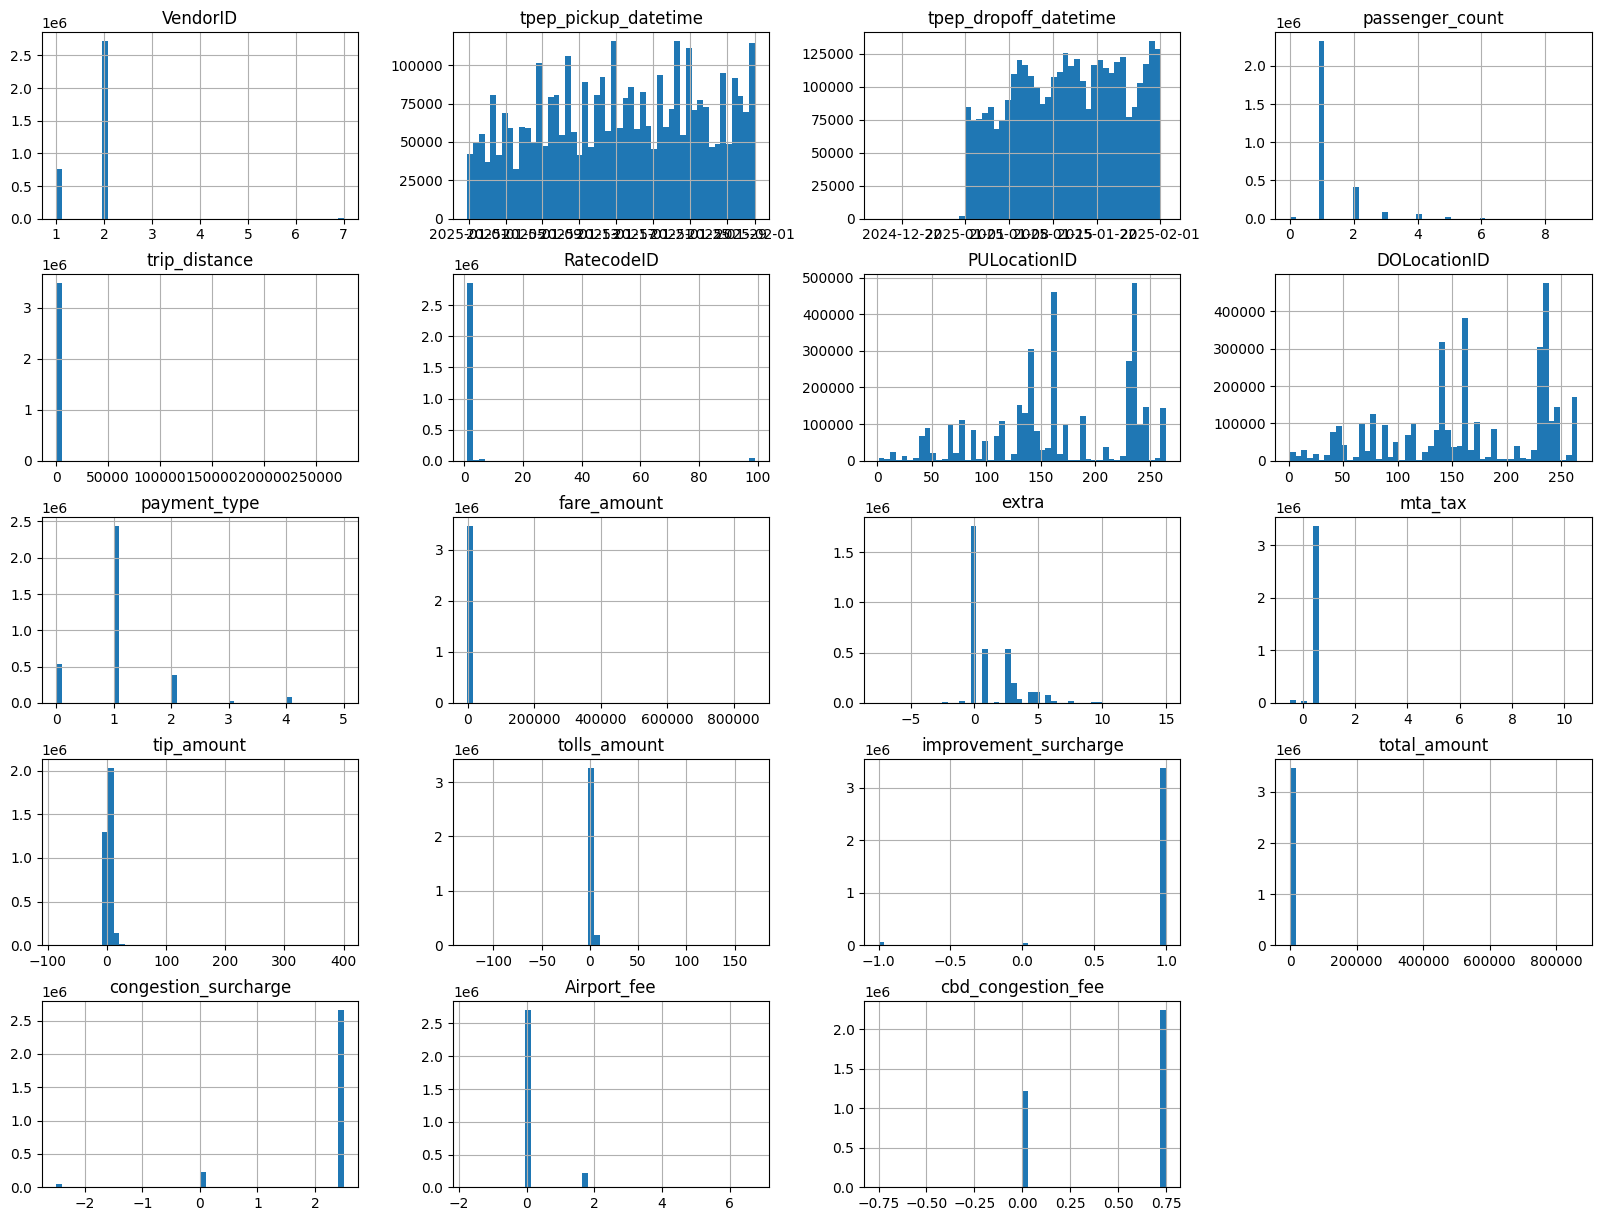

In [8]:
import matplotlib.pyplot as plt
%matplotlib inline

#Uso bins=50 para ver bien los detalles y figsize para que el gráfico sea grande:
taxis.hist(bins=50, figsize=(20,15))

#El comando plt.show() limpia cualquier texto extra y muestra solo los gráficos:
plt.show()

**Algunas observaciones**

1. Las siguientes columnas tienen más valor como columnas categóricas que como columnas numéricas:

- VendorID
- passenger_count
- trip_distance (agrupando las distancias cada 1 km)
- RatecodeID
- PULocationID (luego del mapeo)    
- DOLocationID (luego del mapeo)
- improvement_surcharge
- airport_fee

2. payment_type siempre va a ser 1 porque es la unica forma en que se registra la propina.

#### 2.1.2 Inspección sobre variables categóricas

In [9]:
#Aplico value_counts() sobre las variables categóricas.
for categoria in columnas_cat:
    #Uso un separador con el parámetro end="\n":
    print(taxis[categoria].value_counts(), end="\n\n")

tpep_pickup_datetime
2025-01-23 22:11:00    18
2025-01-23 18:43:00    17
2025-01-22 18:14:00    16
2025-01-31 18:37:00    16
2025-01-11 23:20:00    16
                       ..
2025-01-16 09:06:49     1
2025-01-16 09:04:48     1
2025-01-16 09:03:36     1
2025-01-16 09:21:12     1
2025-01-31 23:26:31     1
Name: count, Length: 1672077, dtype: int64

tpep_dropoff_datetime
2025-01-19 00:00:00    21
2025-01-24 18:41:00    20
2025-01-25 23:41:00    17
2025-02-01 00:00:00    16
2025-01-25 00:00:00    16
                       ..
2025-01-23 14:12:17     1
2025-01-09 14:53:05     1
2025-01-09 15:02:13     1
2025-01-23 13:48:28     1
2025-02-01 00:17:27     1
Name: count, Length: 1671993, dtype: int64

store_and_fwd_flag
N    2927431
Y       7646
Name: count, dtype: int64



## 3 Pipeline: Crear conjunto de prueba

Voy a hacer un Muestreo Estratificado (Stratified Sampling). Esto evita que, en caso de haber una variable categórica significativa, la misma no quede bien representada en un test_set generado por muestreo aleatorio (pues azar)

### 3.1 Correlaciones

#### 3.1.1 Correlaciones en variables numéricas respecto a la variable a predecir

In [10]:
corr_matrix = taxis[columnas_num].corr()
corr_matrix["tip_amount"].sort_values(ascending=False)

tip_amount               1.000000
tolls_amount             0.447300
Airport_fee              0.417118
extra                    0.271233
improvement_surcharge    0.124886
cbd_congestion_fee       0.039199
total_amount             0.032442
congestion_surcharge     0.029795
mta_tax                  0.028990
fare_amount              0.021010
passenger_count          0.020370
VendorID                 0.012824
trip_distance            0.000334
DOLocationID            -0.017333
PULocationID            -0.039499
payment_type            -0.066118
RatecodeID              -0.094625
Name: tip_amount, dtype: float64

Parece que las variables numéricas de mayor impacto sobre "tip_amoutn" son:
- tolls_amount
- Airport_fee             
- extra                   
- improvement_surcharge

#### 3.1.2 Correlación en variables numéricas respecto a ellas mismas

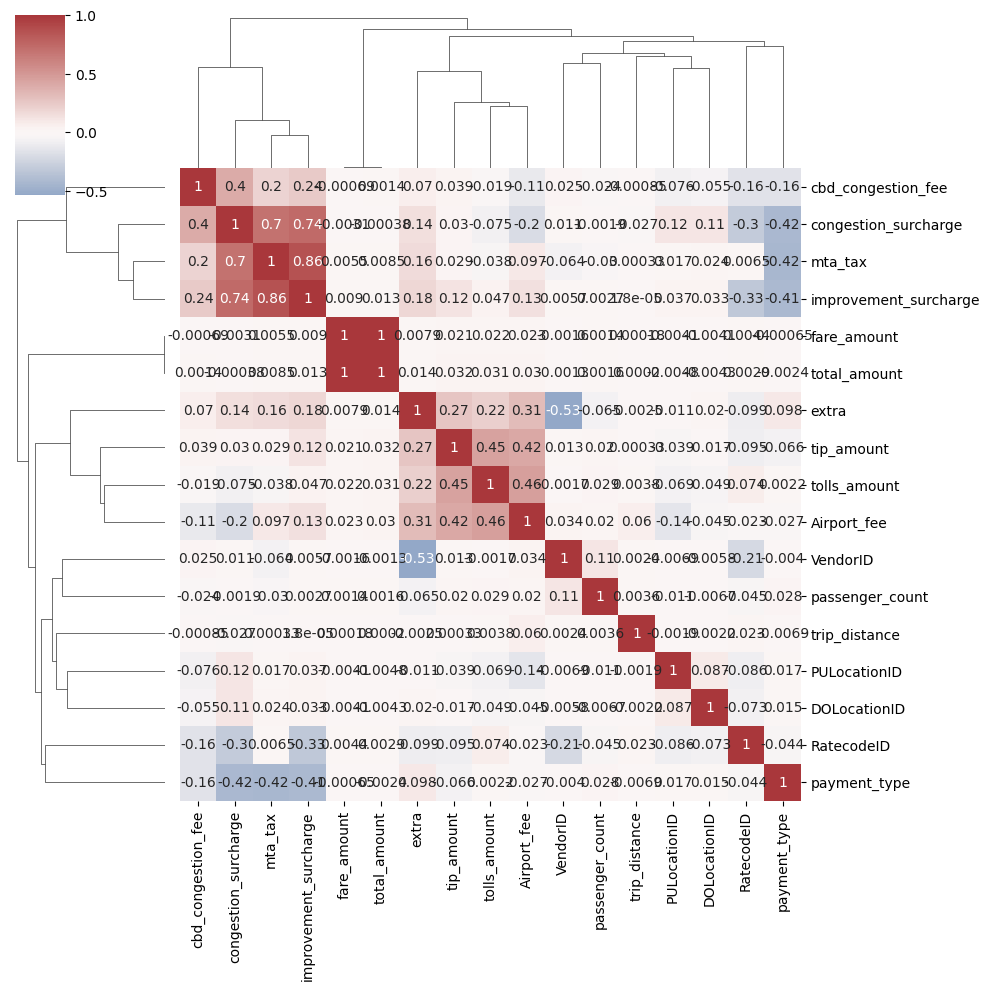

In [11]:
import seaborn as sns
sns.clustermap(taxis[columnas_num].corr(), 
               annot=True, 
               cmap='vlag', 
               center=0)

Veo que hay variables que aportan información redundante, es decir, dada algunas variables, hay otras que dicen cosas similares. Me enfoco en las variables que mejor influyen sobre "tip_amount" obtenidas en el paso anterior y quito las redundantes. Estas son: {tolls_amount, Airport_fee, extra, improvement_surcharge}. Entonces, si tengo:

- Si tengo tolls_amount, redundan: 
1. Airport_fee
2. extra

- Si tengo improvementr_surcharge, redundan:
1. mta_tax
2. congestion_surcharge

#### 3.1.1 Correlaciones en variables categóricas

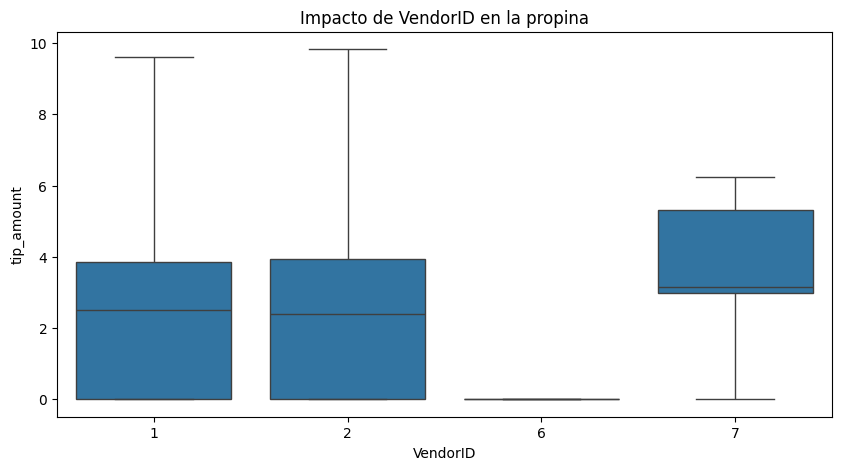

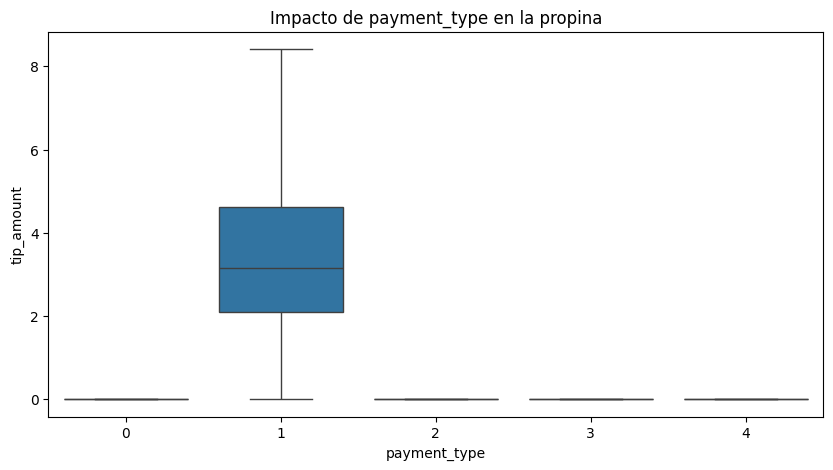

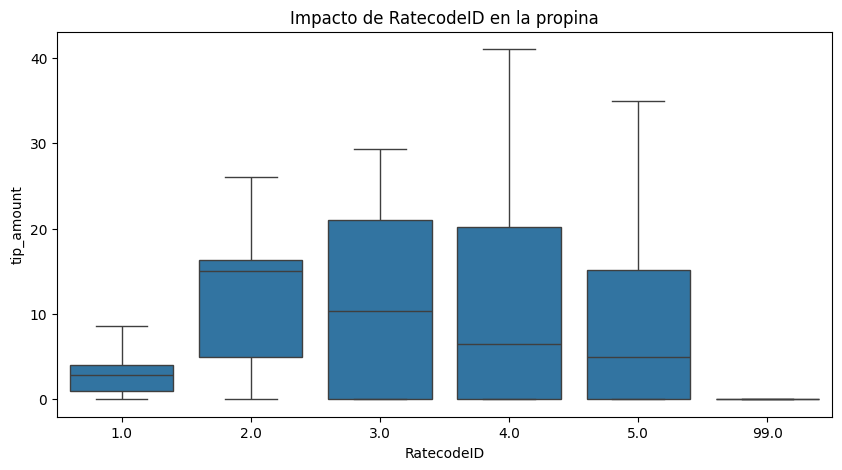

In [12]:
import seaborn as sns
#Muchos datos, no se va a graficar. Me quedo con una muestra aleatoria del 1%
taxis_sample = taxis.sample(frac=0.01, random_state=42)

columnas_cat_clave = ['VendorID', 'payment_type', 'RatecodeID']

for categoria in columnas_cat_clave:
    plt.figure(figsize=(10, 5))
    #showfliers=False oculta los puntos extremos que deforman el box
    sns.boxplot(data=taxis_sample, x=categoria, y="tip_amount", showfliers=False)
    plt.title(f"Impacto de {categoria} en la propina")
    plt.show()

RateCodeID parece ser la variable más importante por varianza entre las categorías. Es la columna que voy a usar al momento de separar los datos con el muestreo estratificado.

### 3.2 Muestreo Estratificado

Primero voy a quitar los NaNs de RatecodeID (la columna objetivo no debe tener nulos). El problema es que esta es una columna con más de 1% de faltanes (tiene 15% de datos faltantes, es mucho) esto lo soluciono con SimpleImputer, pero eso lo hago en un paso posterior, para el cual ya necesito tener hecha la partición (split). 

**Decisión.** Hago una imputación provisoria sobre las filas de RatecodeID. Para esto voy a crear una copia del data set original (taxis_para_split) y voy a trabajar sobre la misma a partir de ahora.

In [13]:
#Creo una copia para el split
taxis_para_split = taxis.copy()

#Imputo un valor centinela (-1) para que la estratificación funcione
taxis_para_split["RatecodeID"] = taxis_para_split["RatecodeID"].fillna(-1)

#Hago el split
#import sys
#import os

#Detecta la carpeta donde está el notebook y sube un nivel a la raíz del proyecto
root_path = os.path.abspath(os.path.join(os.getcwd(), ".."))

if root_path not in sys.path:
    sys.path.append(root_path)

#Importo función de data_split.py:
from src.data_split import split_train_test_stratified

#Llamo a la función con los datos:
train_set, test_set = split_train_test_stratified(taxis_para_split, "RatecodeID")

## 4 Preparar los datos para los algoritmos de Machine Learning

### 4.1 Mapeo y limpieza

In [14]:
#URL oficial del archivo de zonas
zonas_url = "https://d37ci6vzurychx.cloudfront.net/misc/taxi+_zone_lookup.csv"

#Cargo el mapeo
df_zonas = pd.read_parquet(zonas_url) if zonas_url.endswith("parquet") else pd.read_csv(zonas_url)

#Veo que hay:
#df_zonas

**Recuerdo**

Si tengo:

- tolls_amount, redundan: {Airport_fee,extra}

- improvementr_surcharge, redundan: {mta_tax, congestion_surcharge}

In [15]:
from src.data_cleaning import DataSanitizer
from src.pipeline import build_full_pipeline

#Limpieza de filas (Sanitización)
sanitizer = DataSanitizer(df_zonas)
train_set_clean = sanitizer.clean(train_set)

#Separación de variables de entrenamiento y testeo.
X_train = train_set_clean.drop("tip_amount", axis=1)
y_train = train_set_clean["tip_amount"].copy()

**Variables luego del mapeo**

A esta altura tengo dos data frames. train_set y train_set_clean, donde el segundo tiene el mapeo hecho. Voy a ver la diferencia simétrica entre las columnas de ambos data frames.

In [16]:
#Armo conjuntos con las columnas de los data frames:
cols1 = set(train_set.columns)
cols2 = set(train_set_clean.columns)

#Calculo las diferencias específicas:
solo_en_train_set = cols1 - cols2
solo_en_train_set_clean = cols2 - cols1

#Armo un diccionario con las diferencias
pertenencia = {
    "Solo en solo_en_train_set": list(solo_en_train_set),
    "Solo en solo_en_train_set_clean": list(solo_en_train_set_clean)
}

for clave, valor in pertenencia.items():
    print(f"Diferencias encontradas en {clave}: {valor}")
    print("-" * 30)

Diferencias encontradas en Solo en solo_en_train_set: []
------------------------------
Diferencias encontradas en Solo en solo_en_train_set_clean: []
------------------------------


### 4.2 Definición de atributos

In [17]:
#Columnas numéricas:
num_atribs = X_train.select_dtypes(include=[np.number]).columns
num_a_quitar = ["Airport_fee", "extra", "mta_tax", "congestion_surcharge"]
num_atribs_final = [col for col in num_atribs if col not in num_a_quitar]

#Columnas categóricas existentes:
cat_originales = [col for col in X_train.select_dtypes(exclude=[np.number]).columns 
             if X_train[col].nunique() < 10]

#Agrego las columnas que creará el Mapper:
# Como el pipeline va a crear estas columnas, necesito avisarle que las procese.
columnas_mapeadas = ["PU_Borough", "DO_Borough", "PU_Zone", "DO_Zone", "PU_service_zone", "DO_service_zone"]

#Me quedo solo con las que tienen menos de 10 categorías únicas
mapeadas_filtradas = [col for col in columnas_mapeadas 
                      if col in df_zonas.columns and df_zonas[col].nunique() < 10]

cat_atribs = cat_originales + mapeadas_filtradas

#Construcción y aplicación del Pipeline:
full_pipeline = build_full_pipeline(cat_atribs, num_atribs_final, num_a_quitar, df_zonas)
X_train_preparado = full_pipeline.fit_transform(X_train)

In [18]:
print(f"Filas: {X_train_preparado.shape[0]}")
print(f"Columnas: {X_train_preparado.shape[1]}")

Filas: 1895244
Columnas: 14


## 5 Seleccionar y entrenar un modelo

### 5.1 Modelos

#### 5.1.1 Regresión lineal

In [19]:
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()
lin_reg.fit(X_train_preparado, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


#### 5.1.2 Decision Tree

In [20]:
from sklearn.tree import DecisionTreeRegressor

tree_reg = DecisionTreeRegressor(max_depth=12, min_samples_leaf=100, random_state=42)
tree_reg.fit(X_train_preparado, y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,12
,min_samples_split,2
,min_samples_leaf,100
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


#### 5.3 Random forest

In [21]:
from sklearn.ensemble import RandomForestRegressor
#Instancio el modelo
forest_reg = RandomForestRegressor(
    n_estimators=100, 
    max_samples=100000, # Entrena cada árbol con 100k filas elegidas al azar
    n_jobs=-1,          # ¡Fundamental! Usa todos tus núcleos
    max_depth=15,       # Evita que los árboles crezcan hasta el infinito
    random_state=42
)

forest_reg.fit(X_train_preparado, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,15
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


### 5.2 Errores de los modelos

In [22]:
from sklearn.metrics import mean_squared_error

In [23]:
import numpy as np
from sklearn.model_selection import cross_val_score

def medir_error_regresion(modelo, X, y):
    #Agregamos n_jobs=-1 para que los 10 "folds" se procesen en paralelo
    neg_mse_scores = cross_val_score(modelo, X, y, cv=5, # Bajamos a 5 para ganar velocidad
                                     scoring='neg_mean_squared_error', 
                                     n_jobs=-1)
    
    # Pasamos a RMSE (Error Cuadrático Medio Raíz) para que la unidad sea "Dólares"
    rmse_scores = np.sqrt(-neg_mse_scores)
    
    print(f"Modelo: {modelo.__class__.__name__}")
    print(f"RMSE medio: ${rmse_scores.mean():.2f}")
    print(f"Desviación estándar: ${rmse_scores.std():.2f}")
    print("-" * 30)

In [24]:
#Paso los objetos de los modelos, no el resultado del fit
modelos = [lin_reg, tree_reg, forest_reg]

for modelo in modelos:
    medir_error_regresion(modelo, X_train_preparado, y_train)

Modelo: LinearRegression
RMSE medio: $1.16
Desviación estándar: $0.01
------------------------------
Modelo: DecisionTreeRegressor
RMSE medio: $1.12
Desviación estándar: $0.01
------------------------------
Modelo: RandomForestRegressor
RMSE medio: $0.78
Desviación estándar: $0.01
------------------------------


## Guardo los experimentos

In [25]:
import joblib
import os
from sklearn.pipeline import Pipeline

#ENSAMBLAJE CORRECTO:
# Uno el pipeline que ya tiene (Mapeo + Limpieza + Transformación) con el Modelo
modelo_final = Pipeline([
    ("preprocesamiento_completo", full_pipeline), #El objeto que devuelve build_full_pipeline
    ("modelo_entrenado", forest_reg)                 #El Random Forest
])

#PRUEBA DE VIDA (con datos crudos)
try:
    #Uso X_train sin procesar, porque el pipeline debe hacer todo el trabajo
    prueba_x = X_train.iloc[:5] 
    pred = modelo_final.predict(prueba_x)
    print(f" Prueba de predicción exitosa: {pred}")
except Exception as e:
    print(f" Error en el Pipeline: {e}")

#GUARDADO CON VERSIÓN
#Es buena práctica poner el RMSE en el nombre para no confundirte después
nombre_archivo = 'modelo_final_v6.pkl'
ruta_destino = os.path.join('..', 'models', nombre_archivo)

os.makedirs(os.path.dirname(ruta_destino), exist_ok=True)
joblib.dump(modelo_final, ruta_destino)

#print(f" Pipeline completo y modelo guardados en:")
#print(os.path.abspath(ruta_destino))

 Prueba de predicción exitosa: [3.23624449 4.00154686 2.34755833 2.54873657 3.10506391]


['..\\models\\modelo_final_v6.pkl']